In [4]:
import pandas as pd
import numpy as np

In [5]:
matches = pd.read_csv('20_matches.csv')
deliveries = pd.read_csv('20_deliveries.csv')
nov = pd.read_csv('20_reg-month1.csv')
des = pd.read_csv('20_reg-month2.csv')
courses = pd.read_csv('20_courses.csv')
students = pd.read_csv('20_students.csv')

In [6]:
courses.head()

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499


In [7]:
students.head()

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6


In [8]:
nov.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [9]:
des.head()

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9


In [10]:
# sometimes we may need to work on multiple datasests

## concat

In [11]:
#1] concat()
# pd.concat
# ignore_index
# mullitindex -> fetch using iloc
# concat dataframes horizontally

In [12]:
nov

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [13]:
des

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [14]:
pd.concat([nov , des]) # reatins original index

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [15]:
pd.concat([ des , nov]) # order matters

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [16]:
pd.concat([nov , des] , ignore_index = True) # make index normal

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [17]:
multi = pd.concat([nov , des] , keys = ['Nov','Des'])
# reatins original index and also make differentiate between two dataframes => multiindexing Dataframe
multi

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Des 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [18]:
#How to fetach items
multi.loc['Nov']

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [19]:
multi.loc[('Nov',4)]

student_id    16
course_id      9
Name: (Nov, 4), dtype: int64

In [20]:
# multi.loc[('Nov',4:20)] # nahi hota ye

In [21]:
# horizontal concatenation

In [22]:
pd.concat([nov , des] , axis = 1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


In [23]:
# joining

In [24]:
# inner join

In [25]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [26]:
regs = pd.concat([nov,des])
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


## joins

In [27]:
students.merge(regs , how = 'inner' , on='student_id') # nested loop works beyound the scene
# kya ho raha hain
# 1]ek loop chal raha hain students whale table pe wha se ek ek karke student id aa rahi hain , vo id regs wale student_id column me jakar har ek 
# id se puch rahi hain kya hum same hain , agar hain to new df me aajao agar nahi hain to aage badho

#2 ex] student_id from stusents , id = 1
# student_id from regs , got 4 match equals to id = 1
# print all of them in new df

#3] left me kta hain aur right me kinsa df hain mattaer karta hain

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [28]:
regs.merge(students , how = 'inner' , on='student_id') # just changed positions of dataframes

,student_id,course_id,name,partner
0,23,1,Chhavi Lachman,18
1,15,5,Preet Sha,16
2,18,6,Fardeen Mahabir,13
3,23,4,Chhavi Lachman,18
4,16,9,Elias Dodiya,25
5,18,1,Fardeen Mahabir,13
6,1,1,Kailash Harjo,23
7,7,8,Tarun Thaker,9
8,22,3,Yash Sethi,21
9,15,1,Preet Sha,16


In [29]:
# left join

In [30]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [31]:
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [32]:
students.merge(regs , how = 'left' , on = 'student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1.0
1,1,Kailash Harjo,23,6.0
2,1,Kailash Harjo,23,10.0
3,1,Kailash Harjo,23,9.0
4,2,Esha Butala,1,5.0
5,3,Parveen Bhalla,3,3.0
6,3,Parveen Bhalla,3,5.0
7,4,Marlo Dugal,14,NaN
8,5,Kusum Bahri,6,NaN
9,6,Lakshmi Contractor,10,NaN


In [33]:
regs.merge(regs , how = 'left' , on = 'student_id')

,student_id,course_id_x,course_id_y
0,23,1,1
1,23,1,4
2,23,1,3
3,23,1,6
4,23,1,9
...,...,...,...
174,11,10,8
175,11,10,10
176,42,9,9
177,50,8,8


In [34]:
regs.merge(students , how = 'left' , on = 'student_id')

,student_id,course_id,name,partner
0,23,1,Chhavi Lachman,18.0
1,15,5,Preet Sha,16.0
2,18,6,Fardeen Mahabir,13.0
3,23,4,Chhavi Lachman,18.0
4,16,9,Elias Dodiya,25.0
5,18,1,Fardeen Mahabir,13.0
6,1,1,Kailash Harjo,23.0
7,7,8,Tarun Thaker,9.0
8,22,3,Yash Sethi,21.0
9,15,1,Preet Sha,16.0


In [35]:
# right join

In [36]:
regs.merge(students , how = 'right' , on = 'student_id')

,student_id,course_id,name,partner
0,1,1.0,Kailash Harjo,23
1,1,6.0,Kailash Harjo,23
2,1,10.0,Kailash Harjo,23
3,1,9.0,Kailash Harjo,23
4,2,5.0,Esha Butala,1
5,3,3.0,Parveen Bhalla,3
6,3,5.0,Parveen Bhalla,3
7,4,NaN,Marlo Dugal,14
8,5,NaN,Kusum Bahri,6
9,6,NaN,Lakshmi Contractor,10


In [37]:
students.merge(regs , how = 'right' , on = 'student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [38]:
students.merge(students , how = 'right' , on = 'student_id')

,student_id,name_x,partner_x,name_y,partner_y
0,1,Kailash Harjo,23,Kailash Harjo,23
1,2,Esha Butala,1,Esha Butala,1
2,3,Parveen Bhalla,3,Parveen Bhalla,3
3,4,Marlo Dugal,14,Marlo Dugal,14
4,5,Kusum Bahri,6,Kusum Bahri,6
5,6,Lakshmi Contractor,10,Lakshmi Contractor,10
6,7,Tarun Thaker,9,Tarun Thaker,9
7,8,Radheshyam Dey,5,Radheshyam Dey,5
8,9,Nitika Chatterjee,4,Nitika Chatterjee,4
9,10,Aayushman Sant,8,Aayushman Sant,8


In [39]:

# full outer join

In [40]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [41]:
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [42]:
students.merge(regs , how = 'outer' , on = 'student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23.0,1.0
1,1,Kailash Harjo,23.0,6.0
2,1,Kailash Harjo,23.0,10.0
3,1,Kailash Harjo,23.0,9.0
4,2,Esha Butala,1.0,5.0
5,3,Parveen Bhalla,3.0,3.0
6,3,Parveen Bhalla,3.0,5.0
7,4,Marlo Dugal,14.0,NaN
8,5,Kusum Bahri,6.0,NaN
9,6,Lakshmi Contractor,10.0,NaN


In [43]:
regs.merge(students , how = 'outer' , on = 'student_id')

,student_id,course_id,name,partner
0,1,1.0,Kailash Harjo,23.0
1,1,6.0,Kailash Harjo,23.0
2,1,10.0,Kailash Harjo,23.0
3,1,9.0,Kailash Harjo,23.0
4,2,5.0,Esha Butala,1.0
5,3,3.0,Parveen Bhalla,3.0
6,3,5.0,Parveen Bhalla,3.0
7,4,NaN,Marlo Dugal,14.0
8,5,NaN,Kusum Bahri,6.0
9,6,NaN,Lakshmi Contractor,10.0


In [44]:
# inner join => coomon in both
# left join  => all in left
# right join => all in right
# outer join => all in both

In [45]:
# order matters

In [46]:
regs.merge(students , how = 'left' , on = 'student_id')

,student_id,course_id,name,partner
0,23,1,Chhavi Lachman,18.0
1,15,5,Preet Sha,16.0
2,18,6,Fardeen Mahabir,13.0
3,23,4,Chhavi Lachman,18.0
4,16,9,Elias Dodiya,25.0
5,18,1,Fardeen Mahabir,13.0
6,1,1,Kailash Harjo,23.0
7,7,8,Tarun Thaker,9.0
8,22,3,Yash Sethi,21.0
9,15,1,Preet Sha,16.0


In [47]:
students.merge(regs , how = 'left' , on = 'student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1.0
1,1,Kailash Harjo,23,6.0
2,1,Kailash Harjo,23,10.0
3,1,Kailash Harjo,23,9.0
4,2,Esha Butala,1,5.0
5,3,Parveen Bhalla,3,3.0
6,3,Parveen Bhalla,3,5.0
7,4,Marlo Dugal,14,NaN
8,5,Kusum Bahri,6,NaN
9,6,Lakshmi Contractor,10,NaN


In [48]:
regs.merge(students , how = 'right' , on = 'student_id')

,student_id,course_id,name,partner
0,1,1.0,Kailash Harjo,23
1,1,6.0,Kailash Harjo,23
2,1,10.0,Kailash Harjo,23
3,1,9.0,Kailash Harjo,23
4,2,5.0,Esha Butala,1
5,3,3.0,Parveen Bhalla,3
6,3,5.0,Parveen Bhalla,3
7,4,NaN,Marlo Dugal,14
8,5,NaN,Kusum Bahri,6
9,6,NaN,Lakshmi Contractor,10


In [49]:
# left join (a , b) = rigth join(b , a)

## Quetions

In [50]:
# 99% = inner join

In [51]:
# find total revenuue generated

In [52]:
regs.merge(courses , on='course_id')['price'].sum().item()

154247

In [53]:
# total revennue generated month by month

In [54]:
temp_df = pd.concat([nov,des],keys = ['Nov' , 'Des']).reset_index()

In [55]:
temp_df.merge(courses , on = 'course_id').groupby('level_0')['price'].sum()

level_0
Des    65072
Nov    89175
Name: price, dtype: int64

In [56]:
# 3. Print the registration table
# cols -> name -> course -> price

In [57]:
regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


In [58]:
# 4. Plot bar chart for revenue/course

In [59]:
revenue_df = regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

<Axes: xlabel='course_name'>

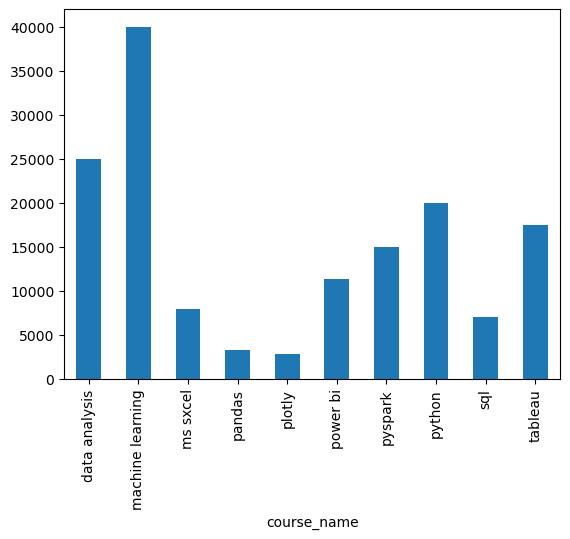

In [60]:
revenue_df.groupby('course_name')['price'].sum().plot(kind = 'bar')

In [61]:
# 5. find students who enrolled in both the months

In [62]:
names = regs.merge(students,on='student_id').value_counts('name')

In [63]:
names = names[names.values > 1]

In [64]:
names = pd.Series(names.index)

In [65]:
names = names.reset_index()

In [66]:
names

,index,name
0,0,Chhavi Lachman
1,1,Tarun Thaker
2,2,Radha Dutt
3,3,Elias Dodiya
4,4,Pranab Natarajan
5,5,Kailash Harjo
6,6,David Mukhopadhyay
7,7,Yash Sethi
8,8,Fardeen Mahabir
9,9,Preet Sha


In [67]:
names.merge(students ,on='name')[['name','student_id']]

,name,student_id
0,Chhavi Lachman,23
1,Tarun Thaker,7
2,Radha Dutt,12
3,Elias Dodiya,16
4,Pranab Natarajan,14
5,Kailash Harjo,1
6,David Mukhopadhyay,11
7,Yash Sethi,22
8,Fardeen Mahabir,18
9,Preet Sha,15


In [68]:
common_student_id = np.intersect1d(nov['student_id'],des['student_id'])
common_student_id

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [69]:
students[students['student_id'].isin(common_student_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [70]:
# 6. find course that got no enrollment
# courses['course_id']
# regs['course_id']

In [71]:
couse_ides = np.setdiff1d(courses['course_id'],regs['course_id'])

In [72]:
courses[courses['course_id'].isin(couse_ides)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [73]:
# 7. find students who did not enroll into any courses

In [74]:
not_enrolled_students = np.setdiff1d(students['student_id'],regs['student_id'])

In [75]:
not_enrolled_students_list =  students[students['student_id'].isin(not_enrolled_students)]

In [76]:
not_enrolled_students_list.shape[0]

7

In [77]:
(7 / 28) *100

25.0

In [78]:
# 8. Print student name -> partner name for all enrolled students

In [79]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [80]:
students.merge(students , on='student_id')

,student_id,name_x,partner_x,name_y,partner_y
0,1,Kailash Harjo,23,Kailash Harjo,23
1,2,Esha Butala,1,Esha Butala,1
2,3,Parveen Bhalla,3,Parveen Bhalla,3
3,4,Marlo Dugal,14,Marlo Dugal,14
4,5,Kusum Bahri,6,Kusum Bahri,6
5,6,Lakshmi Contractor,10,Lakshmi Contractor,10
6,7,Tarun Thaker,9,Tarun Thaker,9
7,8,Radheshyam Dey,5,Radheshyam Dey,5
8,9,Nitika Chatterjee,4,Nitika Chatterjee,4
9,10,Aayushman Sant,8,Aayushman Sant,8


In [81]:
# self join

In [82]:
students.merge(students , left_on='partner' , right_on = 'student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [83]:
students.merge(students , left_on='student_id' , right_on = 'partner') # nested loop

,student_id_x,name_x,partner_x,student_id_y,name_y,partner_y
0,1,Kailash Harjo,23,2,Esha Butala,1
1,2,Esha Butala,1,25,Shashank D’Alia,2
2,3,Parveen Bhalla,3,3,Parveen Bhalla,3
3,4,Marlo Dugal,14,9,Nitika Chatterjee,4
4,5,Kusum Bahri,6,8,Radheshyam Dey,5
5,6,Lakshmi Contractor,10,5,Kusum Bahri,6
6,7,Tarun Thaker,9,17,Yasmin Palan,7
7,8,Radheshyam Dey,5,10,Aayushman Sant,8
8,9,Nitika Chatterjee,4,7,Tarun Thaker,9
9,10,Aayushman Sant,8,6,Lakshmi Contractor,10


In [84]:
# 9. find top 3 students who did most number enrollments

In [85]:
students.merge(regs , on='student_id').value_counts('name').head(3)

name
Chhavi Lachman    6
Tarun Thaker      5
Radha Dutt        4
Name: count, dtype: int64

In [86]:
regs.merge(students,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      6
7           Tarun Thaker        5
14          Pranab Natarajan    4
Name: name, dtype: int64

In [87]:
#find top 3 students who spent most amount of money on courses

In [88]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [89]:
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [90]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [91]:
students.merge(regs , on ='student_id').merge(courses,on='course_id').groupby('name')['price'].sum().sort_values(ascending = False).head(3)

name
Chhavi Lachman      22594
Pranab Natarajan    15096
Qabeel Raman        13498
Name: price, dtype: int64

In [92]:
# Alternate syntax for merge
# students.merge(regs)

pd.merge(students,regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [93]:
# IPL Problems

# find top 3 studiums with highest sixes/match ratio
# find orange cap holder of all the seasons

In [99]:
ipl

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [96]:
ball_by_ball

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [97]:
ipl = matches

In [115]:
temp_df = ipl.merge(ball_by_ball,left_on='id',right_on='match_id')

In [126]:
sixes = temp_df[temp_df['batsman_runs'] == 6].groupby('venue')['id'].count().sort_values(ascending = False)

In [139]:
sixes

venue
M Chinnaswamy Stadium                                   873
Wankhede Stadium                                        657
Feroz Shah Kotla                                        636
Eden Gardens                                            594
MA Chidambaram Stadium, Chepauk                         507
Rajiv Gandhi International Stadium, Uppal               492
Punjab Cricket Association Stadium, Mohali              307
Sawai Mansingh Stadium                                  243
Dr DY Patil Sports Academy                              173
Maharashtra Cricket Association Stadium                 169
Subrata Roy Sahara Stadium                              141
Kingsmead                                               130
Sardar Patel Stadium, Motera                            130
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     129
SuperSport Park                                         120
Brabourne Stadium                                       114
Himachal Pradesh Cricket Associati

In [129]:
matches = ipl.value_counts('venue')

In [130]:
matches

venue
M Chinnaswamy Stadium                                   66
Eden Gardens                                            61
Feroz Shah Kotla                                        60
Wankhede Stadium                                        57
Rajiv Gandhi International Stadium, Uppal               49
MA Chidambaram Stadium, Chepauk                         48
Punjab Cricket Association Stadium, Mohali              35
Sawai Mansingh Stadium                                  33
Dr DY Patil Sports Academy                              17
Subrata Roy Sahara Stadium                              17
Kingsmead                                               15
Maharashtra Cricket Association Stadium                 15
SuperSport Park                                         12
Sardar Patel Stadium, Motera                            12
Brabourne Stadium                                       11
Punjab Cricket Association IS Bindra Stadium, Mohali    11
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadiu

In [135]:
(sixes/matches).sort_values(ascending = False).head(5)

venue
Holkar Cricket Stadium                                 17.600000
M Chinnaswamy Stadium                                  13.227273
Sharjah Cricket Stadium                                12.666667
Himachal Pradesh Cricket Association Stadium           12.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium    11.727273
dtype: float64

In [136]:
# find orange cap holder of all the seasons

In [141]:
temp_df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)

batsman
SK Raina        4548
V Kohli         4423
RG Sharma       4207
G Gambhir       4132
DA Warner       4014
                ... 
RR Bhatkal         0
M Ashwin           0
Abdur Razzak       0
IC Pandey          0
Sunny Gupta        0
Name: batsman_runs, Length: 461, dtype: int64

In [154]:
new_df = temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index()

In [168]:
final_df = new_df.sort_values('batsman_runs',ascending = False).drop_duplicates(subset = ['season'],keep = 'first').sort_values('season')

In [169]:
final_df

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
